# Homework 11


**Concepts covered:**

pandas `DataFrame`s: grouping data, querying `DataFrame`s, joining multiple `DataFrame`s, sampling.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

It is **strictly forbidden to use any generative AI (e.g., ChatGPT, Claude, Gemini, CoPilot or any similar tools**) to write solutions for any assignment. Students who submit work that is not authentically their own individual work will earn a grade of 0 on this assignment.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [2]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.close("all")


**Note: This assignment is partially manually graded, so please allow some time for you to get your final scores.**

**Review Problem 1**

**Concept:** *`DataFrame`: initialization, line plots.*

**Task:**


Using the Starbucks stock dataset:

1. Load the `SBUX.csv` dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Create a line plot showing both the `high` and `low` prices over time.

Your plot should include:

* both high and low columns plotted together
* a title
* a key


                          high        low
date                                     
2025-01-02 14:30:00  92.660004  91.410004
2025-01-03 14:30:00  93.120003  91.800003
2025-01-06 14:30:00  94.500000  91.940002
2025-01-07 14:30:00  93.650002  91.860001
2025-01-08 14:30:00  93.010002  92.010002
...                        ...        ...
2025-12-24 14:30:00  84.620003  83.470001
2025-12-26 14:30:00  85.160004  84.419998
2025-12-29 14:30:00  86.790001  84.980003
2025-12-30 14:30:00  85.750000  85.050003
2025-12-31 14:30:00  85.180000  84.120003

[250 rows x 2 columns]


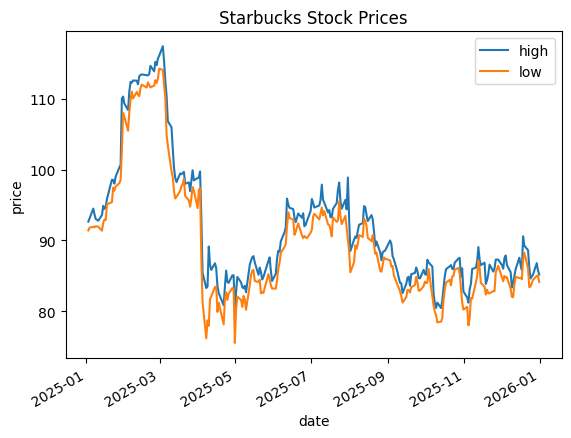

In [3]:
# Your Solution

df_sbux = pd.read_csv('SBUX.csv')
df_sbux['date'] = pd.to_datetime(df_sbux['date'], unit="s")
df_sbux = df_sbux.set_index('date')
df_sbux_new = df_sbux[['high', 'low']]
df_sbux_new.plot()
plt.title('Starbucks Stock Prices')
plt.ylabel('price')
print(df_sbux_new)


Review Problem 2

**Concept:** *`DataFrame`: initialization, descriptive statistics, histogram.*

**Task:**

Using the `SBUX.csv` dataset:

1. Load the dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Compute the **daily return** of the stock using the `close` column (percentage change).
4. Display the **descriptive statistics** of the daily returns.
5. Create a **histogram** of the daily returns using 25 bins.
6. Identify **outliers** where the return falls outside of **mean ± 3 standard deviations**.
7. Print:
    *  the upper and lower bounds
    * the number of values above and below these bounds
    * the list of outlier values (sorted by date)


count    250.000000
mean       0.029498
std        1.868661
min       -5.767048
25%       -1.187872
50%       -0.010913
75%        1.248313
max       10.667568
Name: daily_return, dtype: float64
-5.576485643635303
5.6354823008854655
2
                    formatted_date       high        low       open  \
date                                                                  
2025-04-03 13:30:00     2025-04-03  93.389999  87.650002  93.349998   
2025-04-09 13:30:00     2025-04-09  89.129997  77.930000  79.220001   

                         close    volume   adjclose  daily_return  \
date                                                                
2025-04-03 13:30:00  88.260002  20490100  86.444016     -5.767048   
2025-04-09 13:30:00  88.680000  26668100  86.855362     10.667568   

                     outlier_mask  
date                               
2025-04-03 13:30:00          True  
2025-04-09 13:30:00          True  


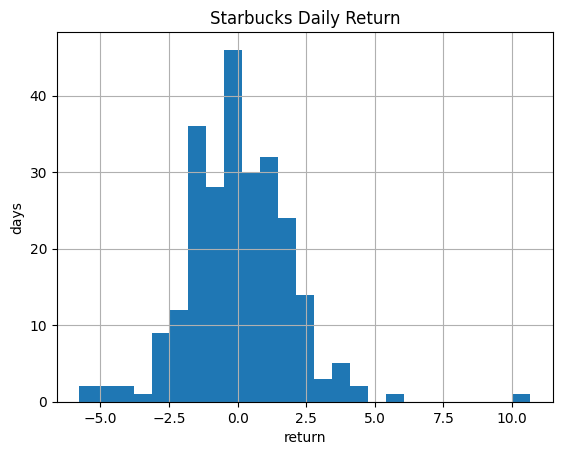

In [4]:
# Your Solution

df_sbux = pd.read_csv("SBUX.csv")
df_sbux['date'] = pd.to_datetime(df_sbux['date'], unit="s")
df_sbux = df_sbux.set_index('date')
df_sbux['daily_return'] = ((df_sbux['close'] - df_sbux['open'])/df_sbux['close'])*100

print(df_sbux['daily_return'].describe())
df_sbux['daily_return'].hist(bins=25)
plt.title('Starbucks Daily Return')
plt.xlabel('return')
plt.ylabel('days')

mean_df_sbux = df_sbux['daily_return'].mean()
std_df_sbux = df_sbux['daily_return'].std()
outlier_lower_bound = mean_df_sbux - 3 * std_df_sbux
outlier_higher_bound = mean_df_sbux + 3 * std_df_sbux
df_sbux['outlier_mask'] = (df_sbux['daily_return'] > outlier_higher_bound) | (df_sbux['daily_return'] < outlier_lower_bound)
df_sbux_new = df_sbux[df_sbux['outlier_mask']]
print(outlier_lower_bound)
print(outlier_higher_bound)
print(len(df_sbux_new))
print(df_sbux_new)



Test case for problem 2

**Problem 3**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Load the dataset into a DataFrame named `df_weather`.
2. Convert the `datetime` column to a pandas datetime format and set it as the index.
3. Use the icon column as a categorical variable and group the data by `icon`.
4. Create a **pie chart** showing the count of each weather icon category.

Your chart should include:
* labels for each category
* a title



/tmp/ipykernel_2556/3257694527.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])


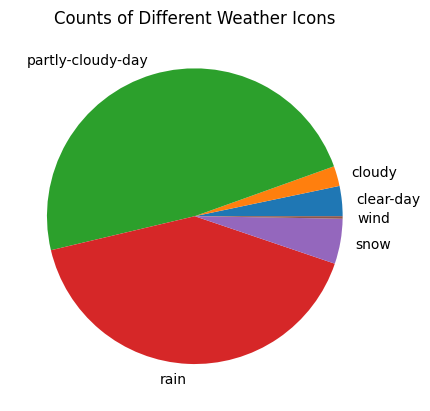

In [20]:
# Your Solution

df_weather = pd.read_csv("02215_weather.csv")

#print(df_weather)

df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])
#print(df_weather['icon'])

iconDf = df_weather.groupby('icon')
iconDf.size().plot(kind='pie', subplots=True)

plt.title('Counts of Different Weather Icons')
plt.show()






**Problem 4**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a **histogram** of the `tempmax` column for each weather condition group.

Your plot should include:
* 25 bins
* transparency so overlapping distributions can be seen
* a legend
* a title


/tmp/ipykernel_2556/2178941835.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


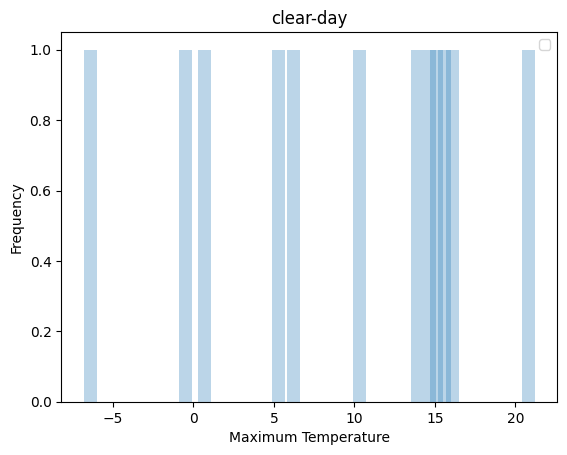

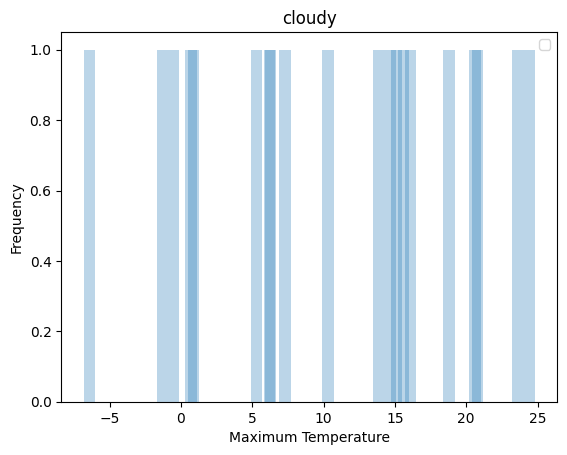

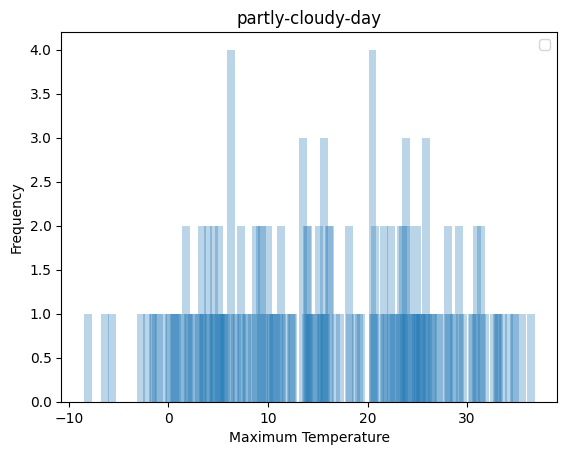

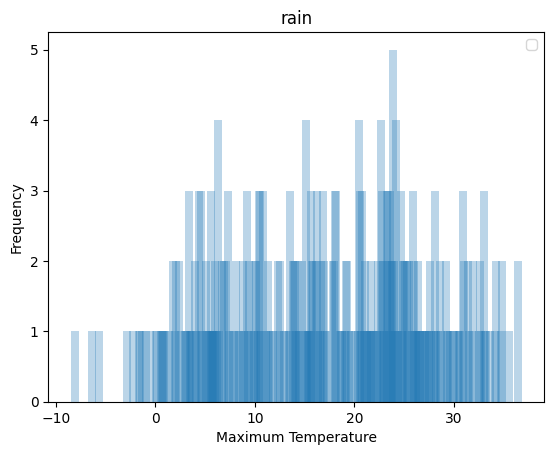

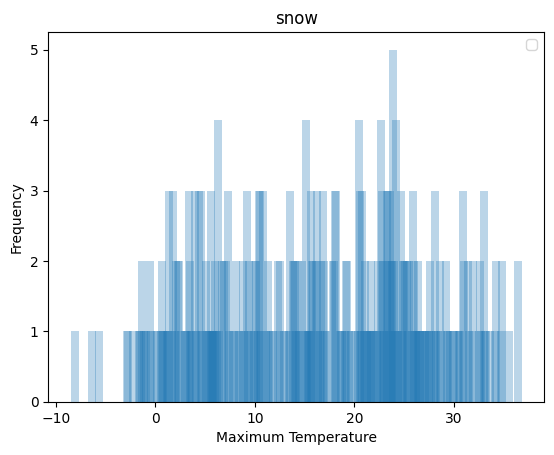

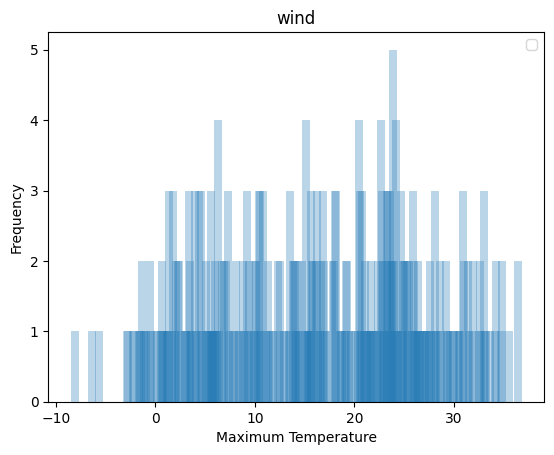

In [22]:
# Your Solution

tempMaxCounts = {} 
 
for label, data in (iconDf):
    tempMaxList = data['tempmax']
    for temp in tempMaxList:
        if temp in tempMaxCounts:
            tempMaxCounts[temp] += 1 
        else:
            tempMaxCounts[temp] = 1 
    #print(tempMaxCounts)
    plt.figure() 
    plt.bar(tempMaxCounts.keys(), tempMaxCounts.values(), alpha=0.3) 
    plt.title(label)
    plt.xlabel("Maximum Temperature")
    plt.ylabel("Frequency")
    plt.legend()

plt.show()

**Problem 5**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a histogram of the `precip` column for each weather condition group.

Your plot should include:

* 10 bins
* transparency so overlapping distributions can be seen
* a legend
* a title



/tmp/ipykernel_2556/4718982.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


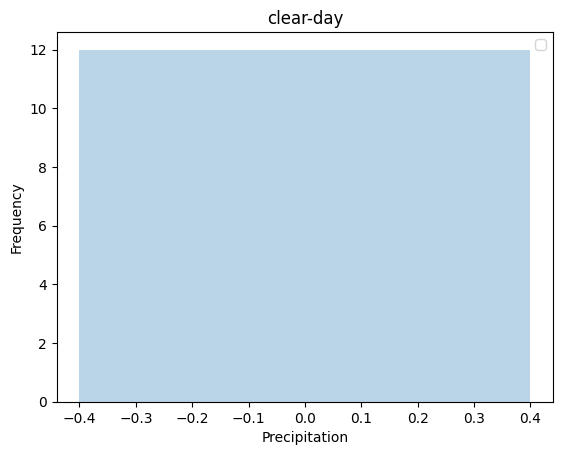

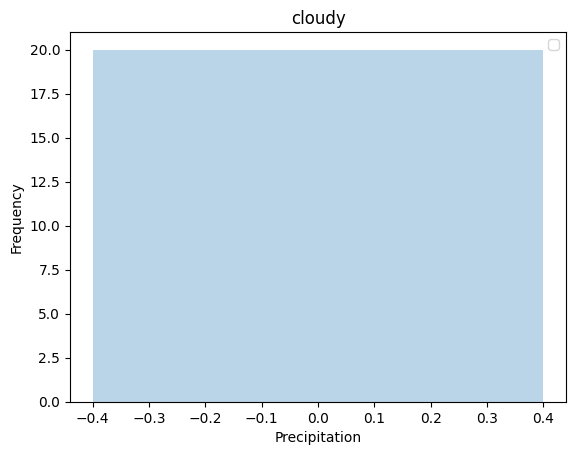

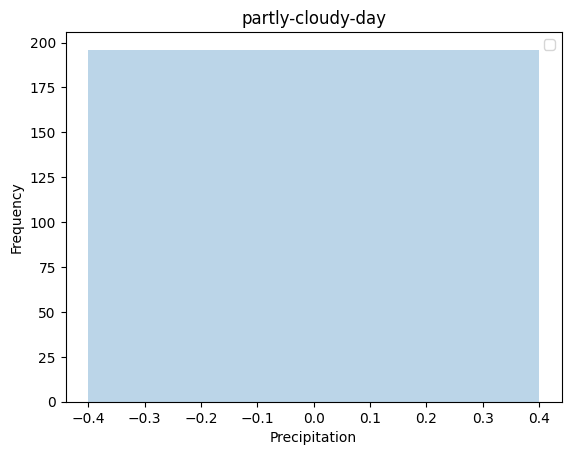

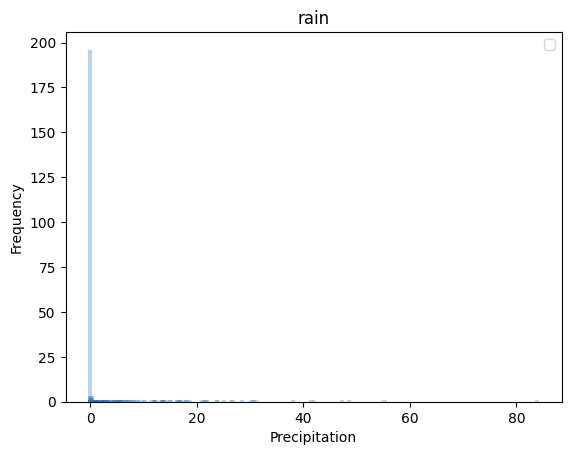

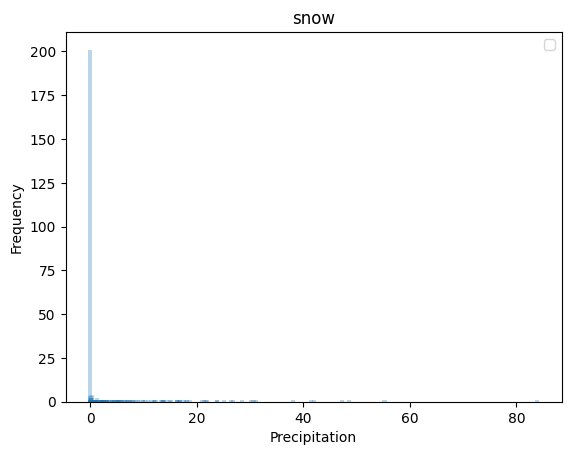

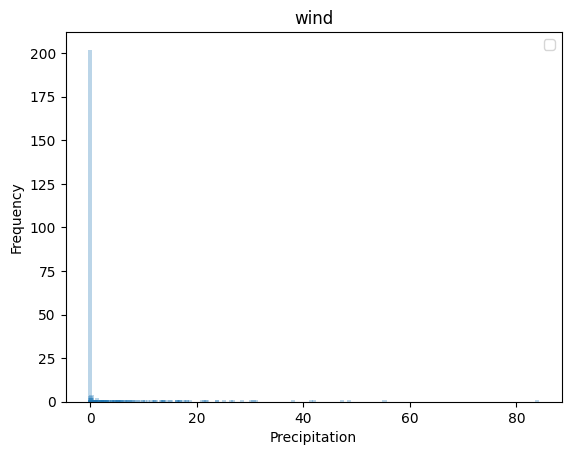

In [24]:
# Your Solution

precipCounts = {} 
 
for label, data in (iconDf):
    precipList = data['precip']
    for prec in precipList:
        if prec in precipCounts:
            precipCounts[prec] += 1 
        else:
            precipCounts[prec] = 1 
    #print(precipCounts)
    plt.figure() # new figure before plotting
    plt.bar(precipCounts.keys(), precipCounts.values(), alpha=0.3) 
    plt.title(label)
    plt.xlabel("Precipitation")
    plt.ylabel("Frequency")
    plt.legend()

plt.show()



**Problem 6**

**Concept:** *Grouping Data, plotting*


**Task:**


Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Compute the **mean** of the `tempmax` column for each weather condition group.
3. Create a **bar chart** to display the mean maximum temperature for each group.


Your plot should include:

* one bar for each weather icon category
* a title



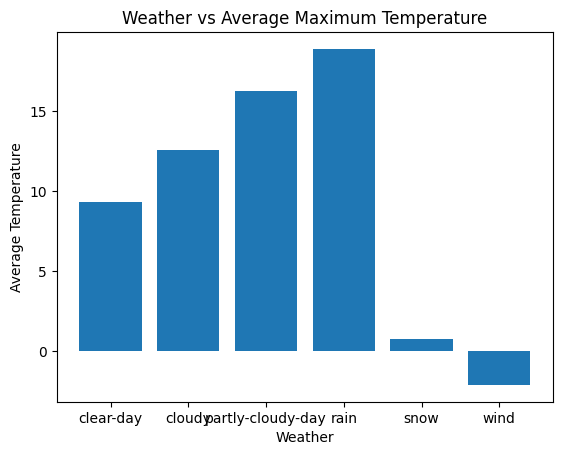

In [25]:
# Your Solution

weatherToAverageTempMax = {} 
 
for label, data in (iconDf):
    #print(label)
    averageTempMax = data['tempmax'].mean()
    #print(averageTempMax)

    weatherToAverageTempMax[label] = averageTempMax


plt.bar(weatherToAverageTempMax.keys(), weatherToAverageTempMax.values())
plt.title("Weather vs Average Maximum Temperature")
plt.xlabel("Weather")
plt.ylabel("Average Temperature")

plt.show()




**Problem 7**

**Concept:** *Grouping data, descriptive statistics*


**Task:**

Using the `02215_weather.csv` dataset:

1. Group the DataFrame by the `icon` column and store the result in a variable named `grouped_by_icon`.
2. Compute descriptive statistics for the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_statistics`.
3. Compute descriptive statistics for the `precip` column for each group and store the result in a variable named `grouped_precipitation_statistics`.
4. Compute the **mean** of the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_mean`.

Print all three results with clear labels:
* `"Tempmax grouped by conditions"`
* `"Precipitation grouped by conditions"`
* `"Mean of tempmax grouped by conditions"`


In [ ]:
# Your Solution

iconDf = df_weather.groupby('icon')

print("Tempmax grouped by conditions")
print(iconDf["tempmax"].describe())

print("Precipitation grouped by conditions")
print(iconDf["precip"].describe())

print("Mean of tempmax grouped by conditions")
print(iconDf["tempmax"].mean().describe())

Tempmax grouped by conditions
                   count       mean        std  min    25%    50%     75%  \
icon                                                                        
clear-day           12.0   9.316667   8.230965 -6.4   4.15  12.10  15.225   
cloudy               8.0  12.575000  10.423565 -1.3   4.95  13.05  21.350   
partly-cloudy-day  176.0  16.246023  10.533554 -8.1   7.20  15.65  25.000   
rain               150.0  18.904000   8.498037  0.8  12.60  19.90  24.600   
snow                18.0   0.750000   1.805628 -2.7  -0.65   1.25   1.775   
wind                 1.0  -2.100000        NaN -2.1  -2.10  -2.10  -2.100   

                    max  
icon                     
clear-day          20.8  
cloudy             24.4  
partly-cloudy-day  36.4  
rain               36.4  
snow                4.0  
wind               -2.1  
Precipitation grouped by conditions
                   count      mean        std    min      25%     50%  \
icon                                

QUERYING

The following data frame will be used in several questions.


In [10]:
# starter code
df_voter_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-11/newton_voters.csv", low_memory=False)
df_voter_data.index = df_voter_data["Voter ID Number"]
df_voter_data['Date of Birth'] = pd.to_datetime(df_voter_data['Date of Birth'])


**Problem 8**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Determine the **total number of voters** and print the result.
2. Compute the count of voters in each **Party Affiliation** category.
3. Create a **pie chart** showing the distribution of voters by party affiliation.

Your plot should include:
* labels for each category
* a title that includes the total number of voters


{'U ': 32416, 'D ': 23108, 'R ': 2854, 'J ': 28, 'A ': 20, 'CC': 110, 'X ': 8, 'L ': 103, 'Q ': 19, 'S ': 14, 'FF': 4, 'G ': 10, 'HH': 1, 'T ': 27, 'AA': 7, 'GG': 3, 'Z ': 5, 'O ': 22, 'P ': 1, 'E ': 1, 'V ': 2, 'H ': 1, 'Y ': 1, 'W ': 1, 'EE': 1, 'K ': 2}


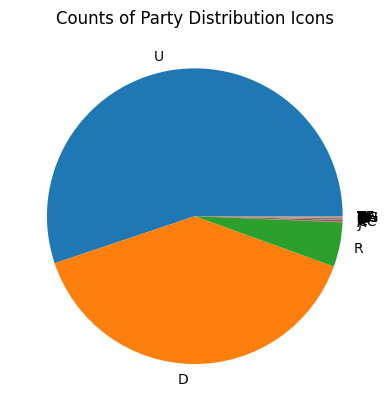

In [ ]:
# Your Solution

totalVoters = 0
partyAffiliations = {} 

#print(df_voter_data)

for party in df_voter_data["Party Affiliation"]:
    totalVoters += 1

    if party in partyAffiliations:
        partyAffiliations[party] += 1
    else:
        partyAffiliations[party] = 1

print(partyAffiliations)
plt.pie(partyAffiliations.values(), labels=partyAffiliations.keys())

plt.title('Counts of Party Distribution Icons')
plt.show()




**Problem 9**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_older_voters` that includes only voters born **before January 1, 1950**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these older voters.

Your plot should include:
* labels for each category
* a title that includes the number of older voters


Voter ID Number
02JHE1841000   1940-10-24
10KSA1343001   1943-12-15
12OJQ0945000   1946-02-16
04KKL1329000   1929-09-01
06PDH2932000   1932-10-02
                  ...    
03BJY0849000   1949-06-13
06RLE1444000   1944-08-27
12RJE2349001   1949-12-22
01RAE2250002   1949-09-06
07REC0249001   1949-07-16
Name: Date of Birth, Length: 9073, dtype: datetime64[us]
Total older voters: 9073
Party Affiliation
U     4381
D     4141
R      520
CC      14
L        5
T        4
O        2
Z        1
Q        1
A        1
AA       1
J        1
K        1
Name: count, dtype: int64


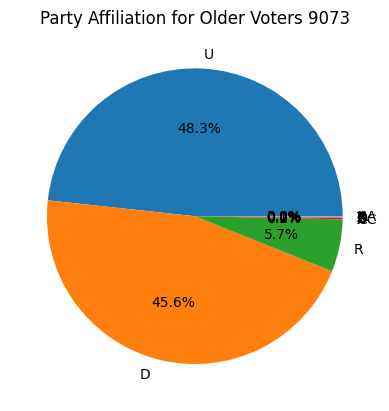

In [ ]:
# Your Solution

df_older_voters = df_voter_data.query("`Date of Birth` < '1950-01-01'")
print(df_older_voters['Date of Birth'])

total_older_voters = len(df_older_voters)
print("Total older voters:", total_older_voters)

party_counts = df_older_voters["Party Affiliation"].value_counts()
print(party_counts)

party_counts.plot.pie(autopct='%1.1f%%')

plt.title(f"Party Affiliation for Older Voters {total_older_voters}")
plt.show()

**Problem 10**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_younger_voters` that includes only voters born **after January 1, 2000**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these Younger voters.

Your plot should include:
* labels for each category
* a title that includes the number of younger voters


Voter ID Number
04FLN1503000   2002-12-27
01OVA0205000   2005-02-02
10CIC0504000   2005-03-03
02CER0602000   2001-12-18
09TAA1003000   2003-07-22
                  ...    
01BKY2102000   2001-08-01
04BBA0700000   2000-02-04
10CJH1300000   2001-03-06
05GCE2104000   2003-12-11
08BME2304000   2004-03-05
Name: Date of Birth, Length: 5099, dtype: datetime64[us]
Total older voters: 5099
Party Affiliation
U     3533
D     1406
R      126
L       17
S        4
CC       3
J        2
A        2
HH       1
P        1
G        1
GG       1
AA       1
X        1
Name: count, dtype: int64


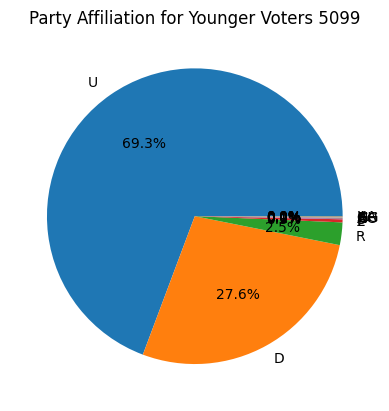

In [ ]:
# Your Solution

df_younger_voters = df_voter_data.query("`Date of Birth` > '2000-01-01'")
print(df_younger_voters['Date of Birth'])

total_younger_voters = len(df_younger_voters)
print("Total older voters:", total_younger_voters)

party_counts = df_younger_voters["Party Affiliation"].value_counts()
print(party_counts)

party_counts.plot.pie(autopct='%1.1f%%')

plt.title(f"Party Affiliation for Younger Voters {total_younger_voters}")
plt.show()


**Problem 11**

**Concept:** *Querying `DataFrame`s and graphing*



**Task:**

Using the `df_voter_data` DataFrame:
1. Identify all columns related to elections:
    * Select columns whose names contain the letter `"v"` but do **not** contain `"score"`
    * Store the result in a variable named `election_columns`

2. Compute the **voting participation percentage** for each election among all voters:
    * Store the result in a variable named `d1`
    * **Hint:** To calculate participation
        * Use `.sum()` on a column to count how many voters participated
        * Divide by the total number of voters using `len(df)`
        * Multiply by 100 to convert to a percentage

3. Create a filtered DataFrame named `df_high_voter_score`:
    * Include only voters with `voter_score >= 4`
    * Print the number of voters in this group

4. Compute the **voting participation percentage** for this group:
    * Store the result in a variable named `d2`

5. Create a filtered DataFrame named `df_unenrolled`:
    * Include only voters with `"Party Affiliation" == "U "`
    * Print the number of voters in this group

6. Compute the voting participation percentage for this group:
    * Store the result in a variable named `d3`

7. Combine the results into a new DataFrame named `d`:
    * Index should be the election columns
    * Columns should be:
        * `"all voters"`
        * `"high-propensity voters"`
        * `"unenrolled voters"`

8. Create a **bar chart** from this combined DataFrame.

Your plot should include:
* a title
* a key

['v20state', 'v21town', 'v21primary', 'v22general', 'v23town']
v20state      41743
v21town       19705
v21primary    12898
v22general    36131
v23town       19936
dtype: int64
58769
High-propensity voters: 15245
Unenrolled voters: 32416


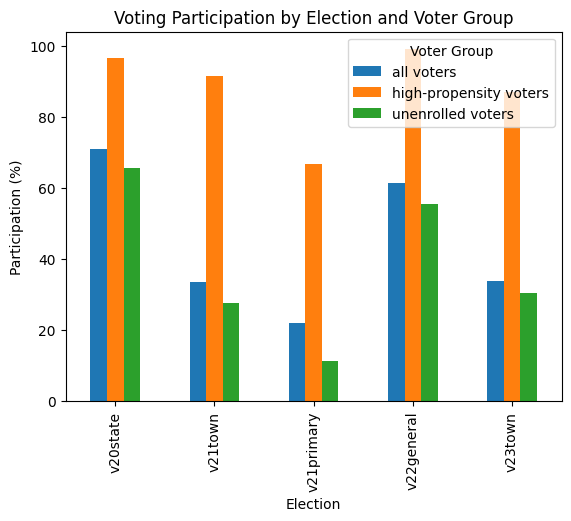

In [27]:
# Your Solution

election_columns = []

for col in df_voter_data.columns:
    if ("v" in col) and ("score" not in col.lower()):
        election_columns.append(col)

print(election_columns)
print(df_voter_data[election_columns].sum())
print(len(df_voter_data))
d1 = (df_voter_data[election_columns].sum() / len(df_voter_data)) * 100

df_high_voter_score = df_voter_data.query("voter_score >= 4")
print("High-propensity voters:", len(df_high_voter_score))

d2 = (df_high_voter_score[election_columns].sum() / len(df_high_voter_score)) * 100

df_unenrolled = df_voter_data.query("`Party Affiliation` == 'U '")
print("Unenrolled voters:", len(df_unenrolled))

d3 = (df_unenrolled[election_columns].sum() / len(df_unenrolled)) * 100

d = pd.DataFrame({
    "all voters": d1,
    "high-propensity voters": d2,
    "unenrolled voters": d3
})

d = d.loc[election_columns]

d.plot(kind='bar')

plt.title("Voting Participation by Election and Voter Group")
plt.xlabel("Election")
plt.ylabel("Participation (%)")
plt.legend(title="Voter Group")
plt.show()

**Problem 12**

**Concept:** *Joining `DataFrame`s*


**Task:**

You are given two DataFrames:
* `submissions`, which contains student IDs and their homework submission IDs
* `grades`, which contains homework grades indexed by submission ID

Using these DataFrames:
1. Inspect both DataFrames by printing them.
2. Join the `submissions` DataFrame with the `grades` DataFrame:
    * Match the `hw1_submission` column in `submissions` with the index of `grades`
    * Store the result in a variable named `result`
3. Update the index of the resulting DataFrame:
    * Set the index to the `student_id` column
4. Create a new DataFrame named `result_df`:
    * Remove the `student_id` column
5. Print the final DataFrame


Starter code:

In [15]:
submissions = pd.DataFrame(data={"student_id": ["U100", "U101", "U102", "U103", "U104"], "hw1_submission": ["c1325", "b231", "a512", "e9999", "d8234"]}) 
grades = pd.DataFrame(index=["a512", "b231", "c1325", "d8234", "e9999"], data={"hw1_grade": [0.99, 0.50, 0.62, 0.78, 1.00]} )


In [16]:
# Your Solution

print("Submissions:")
print(submissions)
print("Grades:")
print(grades)
result = submissions.join(grades, on="hw1_submission")

print("After join:")
print(result)

result = result.set_index("student_id")
result_df = result.drop(columns=[], errors='ignore')

print("Final DataFrame:")
print(result_df)



Submissions:
  student_id hw1_submission
0       U100          c1325
1       U101           b231
2       U102           a512
3       U103          e9999
4       U104          d8234
Grades:
       hw1_grade
a512        0.99
b231        0.50
c1325       0.62
d8234       0.78
e9999       1.00
After join:
  student_id hw1_submission  hw1_grade
0       U100          c1325       0.62
1       U101           b231       0.50
2       U102           a512       0.99
3       U103          e9999       1.00
4       U104          d8234       0.78
Final DataFrame:
           hw1_submission  hw1_grade
student_id                          
U100                c1325       0.62
U101                 b231       0.50
U102                 a512       0.99
U103                e9999       1.00
U104                d8234       0.78


**Problem 13**

**Concept:** *Joining `DataFrame`s*



**Task:**

You are given two datasets:
* `design_materials.tsv`, which contains materials and the quantity required per bed
* `material_costs.tsv`, which contains the cost per unit for each material

Using these datasets:
1. Load both datasets from the provided `.tsv` files using the correct separator.
2. Merge the two DataFrames:
    * Join on the `material` column
    * Store the result in a variable named `df_costs`
3. Create a new column named `cost`:
    * Compute it as:

      **quantity_per_bed × unit_cost**
4. Print the resulting DataFrame

In [17]:
# Your Solution


design_df = pd.read_csv("design_materials.tsv", sep="\t")
cost_df = pd.read_csv("material_costs.tsv", sep="\t")


print("Design Data:")
print(design_df)

print("Material Costs:")
print(cost_df)

df_costs = pd.merge(design_df, cost_df, on="material")

df_costs["cost"] = df_costs["quantity_per_bed"] * df_costs["unit_cost"]


Design Data:
          design                    material  quantity_per_bed
0  4' x 4' x 18"                2" x 6" x 4'                20
1  4' x 4' x 18"  8" x 8" x 16" Cinder Block                12
2  4' x 8' x 18"                2" x 6" x 4'                 6
3  4' x 8' x 18"                2" x 6" x 8'                14
4  4' x 8' x 18"  8" x 8" x 16" Cinder Block                24
5  4' x 4' x 12"                2" x 6" x 4'                16
6  4' x 4' x 12"  8" x 8" x 16" Cinder Block                12
7  4' x 8' x 12"                2" x 6" x 4'                 2
8  4' x 8' x 12"                2" x 6" x 8'                12
9  4' x 8' x 12"  8" x 8" x 16" Cinder Block                24
Material Costs:
                     material  unit_cost
0                2" x 6" x 4'       5.92
1                2" x 6" x 8'       7.62
2  8" x 8" x 16" Cinder Block       3.53


**Problem 14**

**Concept:** *joining `DataFrame`s*


**Task:**

You are given three stock datasets:
* BAC
* GM
* SBUX

Using these datasets:
1. Load each dataset into separate DataFrames:
    * `df_bac`, `df_gm`, and `df_sbux`
2. Convert the `date` column in each DataFrame to pandas datetime format and set it as the index.
3. Create a new DataFrame named `df_stock_prices`:
    * Use the index from `df_bac`
    * Add the following columns:
        * `"bac"` from `df_bac["close"]`
        * `"gm"` from `df_gm["close"]`
        * `"sbux"` from `df_sbux["close"]`
4. Create a **line plot** showing the stock prices over time.

Your plot should include:
* all three stocks on the same chart
* a title

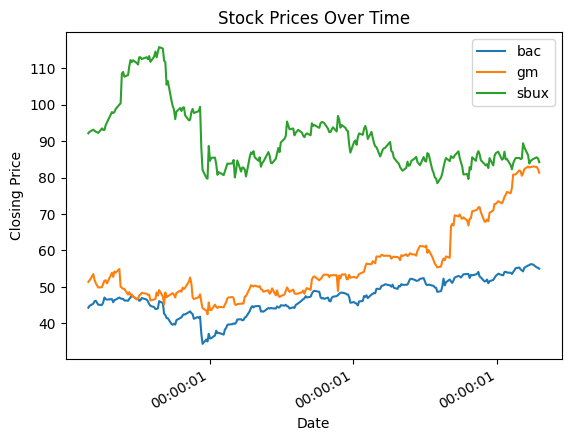

In [29]:
# Your Solution

df_bac = pd.read_csv("BAC.csv")
df_gm = pd.read_csv("GM.csv")
df_sbux = pd.read_csv("SBUX.csv")

for df in [df_bac, df_gm, df_sbux]:
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)

df_stock_prices = pd.DataFrame(index=df_bac.index)

df_stock_prices["bac"] = df_bac["close"]
df_stock_prices["gm"] = df_gm["close"]
df_stock_prices["sbux"] = df_sbux["close"]

df_stock_prices.plot()

plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()


**Problem 15**

**Concept:** *joining `DataFrame`s*


**Task:**

Using the `df_stock_prices` DataFrame from **Problem 14**:
1. Compute the **relative prices** of each stock:
    * Divide all values by the first row of the DataFrame
    * Store the result in a variable named `df_stock_prices_relative`
2. Create a **line plot** of the relative prices.

Your plot should include:
* all three stocks on the same chart
* a title

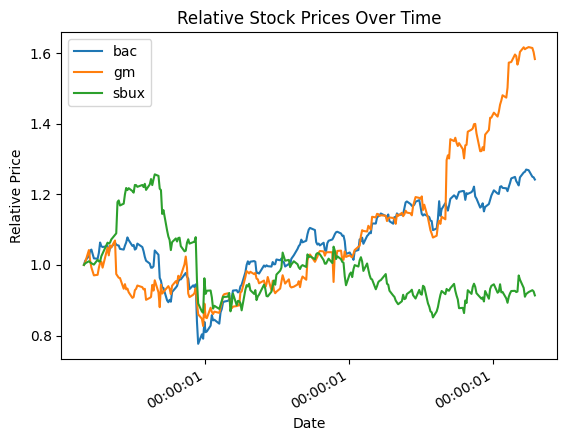

In [ ]:
# Your Solution

df_stock_prices_relative = df_stock_prices/df_stock_prices.iloc[0]
df_stock_prices_relative.plot()

plt.title("Relative Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Relative Price")
plt.legend()
plt.show()